In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [31]:
df=pd.read_csv('Food_Delivery_Times (2).csv')
df

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68
...,...,...,...,...,...,...,...,...,...
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55


In [32]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [33]:
#missing value
df['Weather']=df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level']=df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])
df['Time_of_Day']=df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])
df['Courier_Experience_yrs']=df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean())
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
X=df.drop(columns=['Delivery_Time_min','Order_ID'],axis=1)
y=df['Delivery_Time_min']


In [36]:
numerical_column=X.select_dtypes(include=['int64','float64']).columns
categorical_column=X.select_dtypes(include=['object']).columns

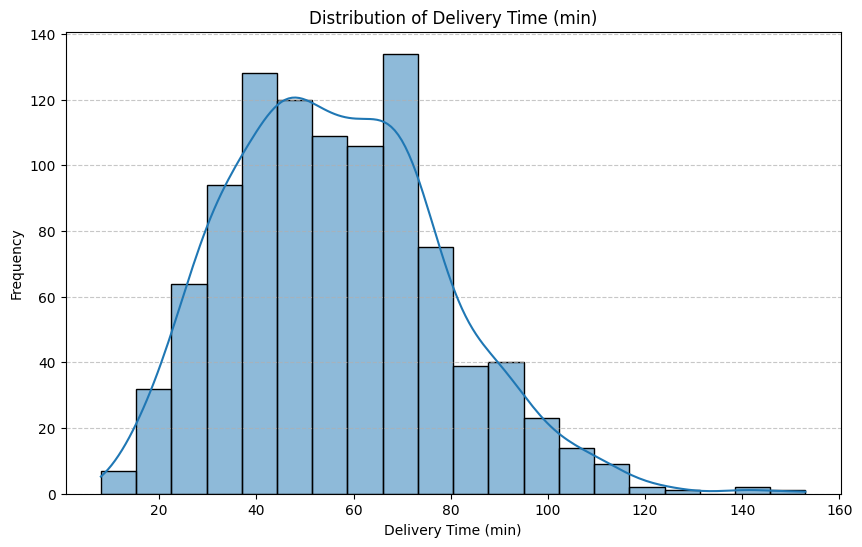

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for Delivery_Time_min
plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=20)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

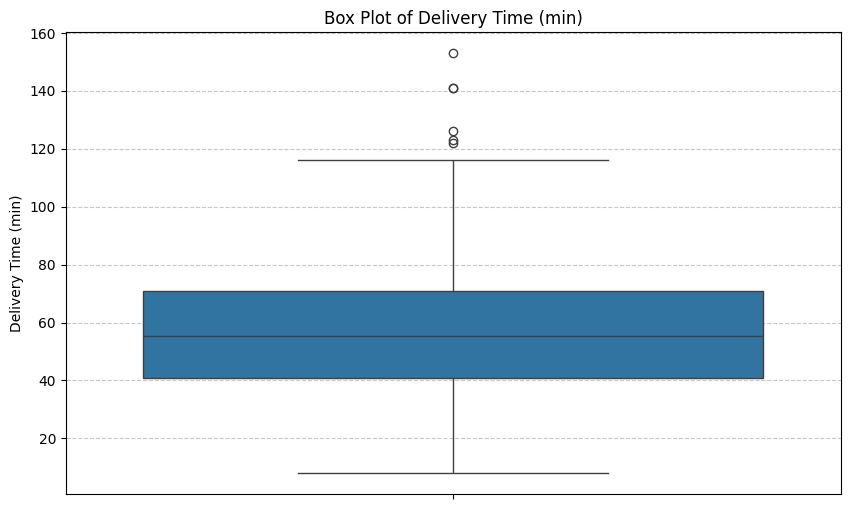

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Box plot for Delivery_Time_min
plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time (min)')
plt.ylabel('Delivery Time (min)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [39]:
#Perform preprocessing
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor=ColumnTransformer(
    transformers=[
        ('num',StandardScaler(),numerical_column),
        ('cat',OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),categorical_column)
    ]
)

In [40]:
#pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
pipeline=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',DecisionTreeRegressor(random_state=42))
    ]
)

In [41]:
# split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [42]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs'], dtype='object')),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='object'))])),
                ('model', DecisionTreeRegressor(random_state=42))])

In [43]:
y_pred=pipeline.predict(X_test)
#model evaluation
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2_score(y_test,y_pred)

0.5019041413114416

In [44]:
#RandomForest
pipeline2=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42

    ))
    ]
)
pipeline2.fit(X_train,y_train)
y_pred=pipeline2.predict(X_test)
#model evaluation
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2_score(y_test,y_pred)


0.7826259036082281

In [45]:
param_distributions = {
    'model__n_estimators': [100, 200, 300, 400, 500], # Renamed key to model__n_estimators
    'model__max_features': ['sqrt', 'log2'], # Renamed key to model__max_features
    'model__max_depth': [10, 20, 30, None], # Renamed key to model__max_depth
    'model__min_samples_split': [2, 5, 10] # Renamed key to model__min_samples_split
}

In [46]:
from sklearn.model_selection import RandomizedSearchCV

In [47]:
random_search = RandomizedSearchCV(
    estimator=pipeline2,
    param_distributions=param_distributions,
    cv=5,
    n_iter=50,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num',
                                                                               StandardScaler(),
                                                                               Index(['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs'], dtype='object')),
                                                                              ('cat',
                                                                               OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                                              unknown_value=-1),
                                                                               Index(['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type'], dtype='object'))])),
                                             ('model',
                                              RandomForestRegressor(max_depth=10,
                                                                    n_estimators=200,
                                                                    random_state=42))]),
                   n_iter=50, n_jobs=-1,
                   param_distributions={'model__max_depth': [10, 20, 30, None],
                                        'model__max_features': ['sqrt', 'log2'],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                400, 500]},
                   random_state=42)

In [48]:
print('Best parameters found by RandomizedSearchCV:')
print(random_search.best_params_)

Best parameters found by RandomizedSearchCV:
{'model__n_estimators': 500, 'model__min_samples_split': 5, 'model__max_features': 'log2', 'model__max_depth': None}


In [49]:
best_model = random_search.best_estimator_
y_pred_best = best_model.predict(X_test)
r2 = r2_score(y_test, y_pred_best)
print(f"R-squared score of the best model: {r2}")

R-squared score of the best model: 0.7849002006379915


In [50]:
import joblib

# Save the best model
joblib.dump(best_model, 'best_random_forest_model.joblib')
print("Best model saved as 'best_random_forest_model.joblib'")

Best model saved as 'best_random_forest_model.joblib'
